Лабораторная 1. Многослойный персептрон

Цель - создать архитектуру многослойного персептрона, классифицирующего грибы (mushroom_dataset).

Описание датасета - https://archive.ics.uci.edu/ml/datasets/Mushroom

Должно быть реализовано:
- 2 скрытых слоя, функция активации сигмоида, градиентный спуск без оптимизаторов.
- Выходных нейрона 2, по количеству классов.
- Обучить нейронную сеть.
- Посчитать accuracy, precision, recall, F1-меру.
- Вывести ROC-кривую.

# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from category_encoders import TargetEncoder

from pprint import pprint
from dotenv import load_dotenv

from ucimlrepo import fetch_ucirepo

In [2]:
load_dotenv()
sklearn.set_config(transform_output="pandas")


from src.layers import LinearLayer
from src.activations import ReLUActivation, SigmoidActivation
from src.losses import BCELoss, CrossEntropyLoss
from src.data_loaders import ShuffleLoader
from src.optimizers import GDOptimizer
from src.models import MLP

# Данные

## Загружаем данные

In [3]:
# Загружаем датасет
mushroom = fetch_ucirepo(id=73)

# Разбиваем на объекты с признаками и объекты с метками
X = mushroom.data.features
y = mushroom.data.targets

In [3]:
from src.data_loaders import datasets
sklearn.set_config(transform_output="default")
X_train, X_val, X_test, y_train, y_val, y_test = datasets.load_mushroom_dataset(targets_shape=2)

## Исследуем данные

In [4]:
# Метаданные
pprint(mushroom.metadata)

{'abstract': 'From Audobon Society Field Guide; mushrooms described in terms '
             'of physical characteristics; classification: poisonous or edible',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'This data set includes descriptions of '
                                'hypothetical samples corresponding to 23 '
                                'species of gilled mushrooms in the Agaricus '
                                'and Lepiota Family (pp. 500-525).  Each '
                                'species is identified as definitely edible, '
                                'definitely poisonous, or of unknown edibility '
                                'and not recommended. 

In [5]:
# Информация о переменных
mushroom.variables

,name,role,type,demographic,description,units,missing_values
0,poisonous,Target,Categorical,None,None,None,no
1,cap-shape,Feature,Categorical,None,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",None,no
2,cap-surface,Feature,Categorical,None,"fibrous=f,grooves=g,scaly=y,smooth=s",None,no
3,cap-color,Feature,Binary,None,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",None,no
4,bruises,Feature,Categorical,None,"bruises=t,no=f",None,no
5,odor,Feature,Categorical,None,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",None,no
6,gill-attachment,Feature,Categorical,None,"attached=a,descending=d,free=f,notched=n",None,no
7,gill-spacing,Feature,Categorical,None,"close=c,crowded=w,distant=d",None,no
8,gill-size,Feature,Categorical,None,"broad=b,narrow=n",None,no
9,gill-color,Feature,Categorical,None,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",None,no


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [7]:
print('Процент Nan данных для stalk-root:', round(1 - 5644/8124, 3))

Процент Nan данных для stalk-root: 0.305


In [8]:
pd.concat([X, y], axis=1).describe()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


In [9]:
for col in X.columns:
    print(f"{col}: {X[col].unique()}")

cap-shape: ['x' 'b' 's' 'f' 'k' 'c']
cap-surface: ['s' 'y' 'f' 'g']
cap-color: ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']
bruises: ['t' 'f']
odor: ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']
gill-attachment: ['f' 'a']
gill-spacing: ['c' 'w']
gill-size: ['n' 'b']
gill-color: ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
stalk-shape: ['e' 't']
stalk-root: ['e' 'c' 'b' 'r' nan]
stalk-surface-above-ring: ['s' 'f' 'k' 'y']
stalk-surface-below-ring: ['s' 'f' 'y' 'k']
stalk-color-above-ring: ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
stalk-color-below-ring: ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']
veil-type: ['p']
veil-color: ['w' 'n' 'o' 'y']
ring-number: ['o' 't' 'n']
ring-type: ['p' 'e' 'l' 'f' 'n']
spore-print-color: ['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']
population: ['s' 'n' 'a' 'v' 'y' 'c']
habitat: ['u' 'g' 'm' 'd' 'p' 'w' 'l']


## Подготавливаем данные

In [10]:
# Индентифицируем метки классов
labels = {
    0: 'edible',
    1: 'poisonous'
}

In [11]:
# Инструменты для предобработки
label_encoder = LabelEncoder()
target_encoder = TargetEncoder(cols=['cap-shape', 'cap-color', 'odor', 'gill-color', 'stalk-color-above-ring',
                                     'stalk-color-below-ring', 'spore-print-color' ,'population', 'habitat'])
minmax_scaler = MinMaxScaler()

# Кодируем метки
y_prep = (y == 'p').astype(int)
# Кодируем бинарные признаки
X_prep = X.copy()
X_prep['bruises'] = (X_prep['bruises'] == 'f').astype(int)
X_prep['gill-attachment'] = (X_prep['gill-attachment'] == 'f').astype(int)
X_prep['gill-spacing'] = (X_prep['gill-spacing'] == 'c').astype(int)
X_prep['gill-size'] = (X_prep['gill-size'] == 'b').astype(int)
X_prep['stalk-shape'] = (X_prep['stalk-shape'] == 't').astype(int)
# Удаляем ненужные признаки
X_prep = X_prep.drop('veil-type', axis=1)
# Кодируем признаки с менее 6 уникальными значениями
X_prep['cap-surface'] = label_encoder.fit_transform(X_prep['cap-surface'])
X_prep['stalk-root'] = label_encoder.fit_transform(X_prep['stalk-root'])
X_prep['stalk-surface-above-ring'] = label_encoder.fit_transform(X_prep['stalk-surface-above-ring'])
X_prep['stalk-surface-below-ring'] = label_encoder.fit_transform(X_prep['stalk-surface-below-ring'])
X_prep['veil-color'] = label_encoder.fit_transform(X_prep['veil-color'])
X_prep['ring-number'] = label_encoder.fit_transform(X_prep['ring-number'])
X_prep['ring-type'] = label_encoder.fit_transform(X_prep['ring-type'])
# Кодируем признаки с более 6 уникальными значениями
target_encoder.fit(X_prep, y_prep)
X_prep = target_encoder.transform(X_prep)

# Нормализуем данные
minmax_scaler.fit(X_prep)
X_prep = minmax_scaler.transform(X_prep)
X_prep.describe()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.608077,0.609224,0.457304,0.584441,0.481643,0.974151,0.838503,0.690793,0.481342,0.567208,...,0.525029,0.534548,0.481254,0.481032,0.655178,0.534712,0.572994,0.469327,0.683776,0.547064
std,0.195081,0.409958,0.247560,0.492848,0.484842,0.158695,0.368011,0.462195,0.339478,0.495493,...,0.207153,0.225325,0.261088,0.255499,0.080890,0.135532,0.450418,0.387048,0.345479,0.249614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.583696,0.000000,0.353642,0.000000,0.034014,1.000000,1.000000,0.000000,0.156659,0.000000,...,0.333333,0.333333,0.383513,0.383212,0.666667,0.500000,0.000000,0.088898,0.418287,0.390988
50%,0.583696,0.666667,0.371153,1.000000,0.034014,1.000000,1.000000,1.000000,0.428817,1.000000,...,0.666667,0.666667,0.383513,0.383212,0.666667,0.500000,0.500000,0.754144,0.536924,0.457141
75%,0.626509,1.000000,0.693950,1.000000,1.000000,1.000000,1.000000,1.000000,0.721244,1.000000,...,0.666667,0.666667,0.692308,0.692308,0.666667,0.500000,1.000000,0.754144,1.000000,0.807540
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# Кодируем метки
y_prep = (y == 'p').astype(int)
# Кодируем бинарные признаки
X_prep = X.copy()
X_prep['bruises'] = (X_prep['bruises'] == 'f').astype(int)
X_prep['gill-attachment'] = (X_prep['gill-attachment'] == 'f').astype(int)
X_prep['gill-spacing'] = (X_prep['gill-spacing'] == 'c').astype(int)
X_prep['gill-size'] = (X_prep['gill-size'] == 'b').astype(int)
X_prep['stalk-shape'] = (X_prep['stalk-shape'] == 't').astype(int)
# Удаляем ненужные признаки
X_prep = X_prep.drop('veil-type', axis=1)
# Остальные кодируем с помощью one-hot-encoding
X_prep = pd.get_dummies(X_prep, columns=['cap-surface', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'veil-color', 'ring-number', 'ring-type',
                                         'cap-shape', 'cap-color', 'odor', 'gill-color', 'stalk-color-above-ring', 'stalk-color-below-ring', 'spore-print-color' ,'population', 'habitat']).astype(int)

X_prep.describe()

,bruises,gill-attachment,gill-spacing,gill-size,stalk-shape,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,stalk-root_b,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.584441,0.974151,0.838503,0.690793,0.567208,0.285574,0.000492,0.314623,0.399311,0.464796,...,0.153619,0.497292,0.210734,0.387494,0.264402,0.102413,0.035943,0.140817,0.045298,0.023634
std,0.492848,0.158695,0.368011,0.462195,0.495493,0.451715,0.022185,0.464394,0.489787,0.498790,...,0.360605,0.500023,0.407855,0.487208,0.441041,0.303209,0.186159,0.347854,0.207969,0.151914
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# Инструменты для предобработки
label_encoder = LabelEncoder()

# Кодируем метки
y_prep = (y == 'p').astype(int)
# Кодируем все признаки
X_prep = X.copy()
cols = X_prep.keys()
for col in cols:
    new_col = str(col) + "_n"
    X_prep[new_col] = label_encoder.fit_transform(X_prep[col])

for col in cols:
    del X_prep[col]

X_prep.describe()

,cap-shape_n,cap-surface_n,cap-color_n,bruises_n,odor_n,gill-attachment_n,gill-spacing_n,gill-size_n,gill-color_n,stalk-shape_n,...,stalk-surface-below-ring_n,stalk-color-above-ring_n,stalk-color-below-ring_n,veil-type_n,veil-color_n,ring-number_n,ring-type_n,spore-print-color_n,population_n,habitat_n
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.0,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,0.567208,...,1.603644,5.816347,5.794682,0.0,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,0.495493,...,0.675974,1.901747,1.907291,0.0,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,...,1.000000,6.000000,6.000000,0.0,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,1.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,1.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,1.000000,...,3.000000,8.000000,8.000000,0.0,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000


In [14]:
# Разделяем на выборки
X_train, X_test, y_train, y_test = map(np.array, train_test_split(X_prep, y_prep, test_size=0.2, random_state=42, shuffle=True, stratify=y_prep))
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True, stratify=y_train)

# Модель

In [4]:
# Задаём архитектуру модели и создаём модель
model = MLP([
    LinearLayer(in_features=X_train.shape[1], out_features=25, bias=True), SigmoidActivation(),
    LinearLayer(in_features=25, out_features=25, bias=True), SigmoidActivation(),
    LinearLayer(in_features=25, out_features=2, bias=True), SigmoidActivation()
])
# Инициализируем Loss и оптимизатор
loss = BCELoss()
# loss = CrossEntropyLoss()
data_loader = ShuffleLoader(batch_size=4)
optimizer = GDOptimizer(
    model_weights_layers=model.get_weights_layers(),
    data_loader=data_loader,
    lr=0.001
)

In [5]:
def postprocess(y_probs: np.ndarray) -> np.ndarray:
    if y_probs.shape[1] == 1:
        y_preds = (y_probs >= 0.5).astype(int)
    else:
        y_preds = np.zeros_like(y_probs, dtype=int)
        max_indices = np.argmax(y_probs, axis=1)
        y_preds[np.arange(y_probs.shape[0]), max_indices] = 1
    
    return y_preds

# Обучение

In [6]:
# Задаём параметры обучения и запускаем его
n_epochs = 10
verbose_n_batch_multiple = 10
model.train_model(
    n_epochs,
    X_train, y_train, X_val, y_val,
    loss, optimizer,
    postprocess=postprocess, count_metric=accuracy_score,
    verbose_n_batch_multiple=verbose_n_batch_multiple
)

Epoch 1 (0/5199):	Train BCELoss = 0.182	Val BCELoss = 0.182	accuracy_score = 0.482
Epoch 1 (40/5199):	Train BCELoss = 0.198	Val BCELoss = 0.198	accuracy_score = 0.482
Epoch 1 (80/5199):	Train BCELoss = 0.204	Val BCELoss = 0.204	accuracy_score = 0.482
Epoch 1 (120/5199):	Train BCELoss = 0.208	Val BCELoss = 0.208	accuracy_score = 0.482
Epoch 1 (160/5199):	Train BCELoss = 0.212	Val BCELoss = 0.212	accuracy_score = 0.482
Epoch 1 (200/5199):	Train BCELoss = 0.218	Val BCELoss = 0.218	accuracy_score = 0.482
Epoch 1 (240/5199):	Train BCELoss = 0.223	Val BCELoss = 0.223	accuracy_score = 0.482
Epoch 1 (280/5199):	Train BCELoss = 0.229	Val BCELoss = 0.229	accuracy_score = 0.482
Epoch 1 (320/5199):	Train BCELoss = 0.233	Val BCELoss = 0.233	accuracy_score = 0.482
Epoch 1 (360/5199):	Train BCELoss = 0.237	Val BCELoss = 0.237	accuracy_score = 0.482
Epoch 1 (400/5199):	Train BCELoss = 0.24	Val BCELoss = 0.24	accuracy_score = 0.482
Epoch 1 (440/5199):	Train BCELoss = 0.245	Val BCELoss = 0.245	accuracy_

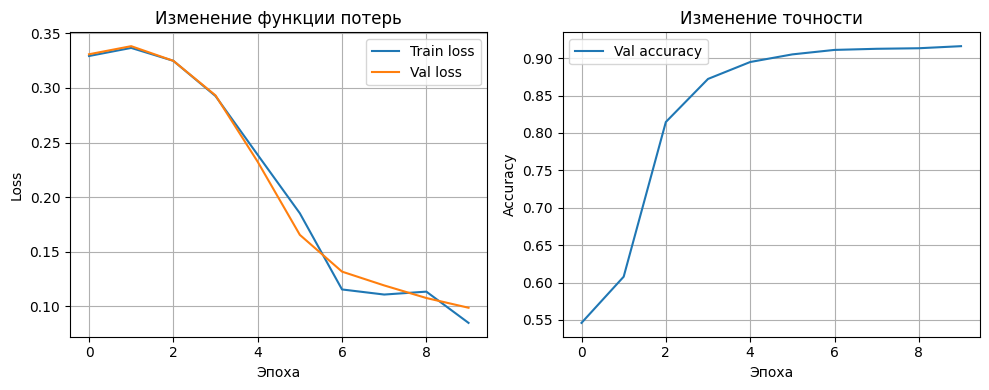

In [7]:
# Строим графики
plt.figure(figsize=(10, 4))

# --- График потерь ---
plt.subplot(1, 2, 1)
plt.plot(model.losses_train, label='Train loss')
plt.plot(model.losses_val, label='Val loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Изменение функции потерь')
plt.legend()
plt.grid(True)

# --- График точности ---
plt.subplot(1, 2, 2)
plt.plot(model.metrics_val, label='Val accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Изменение точности')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Тестирование

In [8]:
# Проверка на предсказаниях
model.eval()
y_prob = model(X_test)
y_pred = postprocess(y_prob)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       842
           1       0.93      0.93      0.93       783

   micro avg       0.93      0.93      0.93      1625
   macro avg       0.93      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625
 samples avg       0.93      0.93      0.93      1625



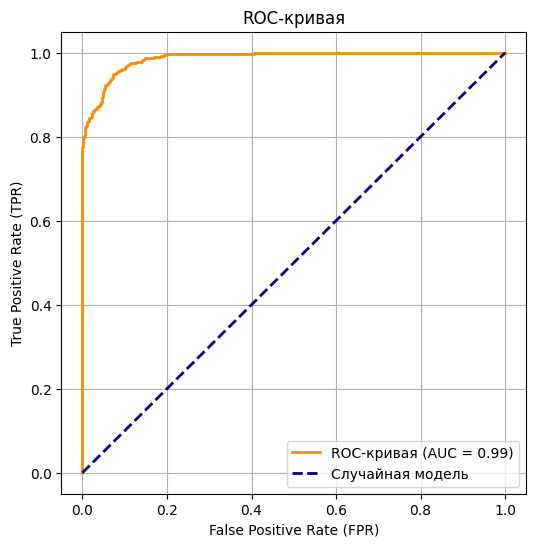

In [9]:
# Вычисляем координаты ROC-кривой
roc_y_true = y_test.argmax(axis=1) if y_test.shape[1] == 2 else y_test.squeeze()
roc_y_prob = y_prob[:, 1] if y_prob.shape[1] == 2 else y_prob.squeeze()
fpr, tpr, thresholds = roc_curve(roc_y_true, roc_y_prob)
# Площадь под кривой (AUC)
roc_auc = auc(fpr, tpr)

# Визуализация ROC-кривой
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# # Temp for testing with torch

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import TensorDataset, DataLoader

# # Допустим у нас данные
# # X_train: [n_samples, n_features]
# # y_train: [n_samples,]

# # Датасет и загрузчик
# dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
# dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# # Определяем MLP модель
# class MLP(nn.Module):
#     def __init__(self, input_dim):
#         super(MLP, self).__init__()
        
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, 50),
#             nn.Sigmoid(),
#             nn.Linear(50, 2),
#             nn.Sigmoid()
#         )
        
#     def forward(self, x):
#         return self.model(x)

# # Создаем модель
# model = MLP(X_train.shape[1])

# # Оптимизатор и функция потерь
# criterion = nn.BCELoss()
# optimizer = optim.SGD(model.parameters(), lr=0.001)

# Цикл обучения
# n_epochs = 15
# for epoch in range(n_epochs):
#     for X_batch, y_batch in dataloader:
#         # forward
#         y_pred = model(X_batch)
#         loss = criterion(y_pred, y_batch)
        
#         # backward
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
    
#     print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
# # Проверка на предсказаниях
# with torch.no_grad():
#     y_pred = model.predict(torch.Tensor(X_test), postprocess)
#     print(classification_report(y_test, y_pred))

Accuracy: 0.8609230769230769
